In [17]:
import pandas as pd
import numpy as np
import re
from scripts import mcmc

#import matplotlib
#matplotlib.use('QtAgg')
%matplotlib inline
import matplotlib.pyplot as plt

NUM = re.compile(r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?")

In [18]:
df = pd.read_csv("results/08_04_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']
values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

# ignore the 1e+33 values
ignore_args = np.where(values_arr!=1e+33)
gap1_vals = params_arr[:,3]
theta_vals = params_arr[:,0]
gap1_vals = gap1_vals[ignore_args]
values_arr = values_arr[ignore_args]
theta_vals = theta_vals[ignore_args]
wid_arr = wid_arr[ignore_args]
params_arr = params_arr[ignore_args]

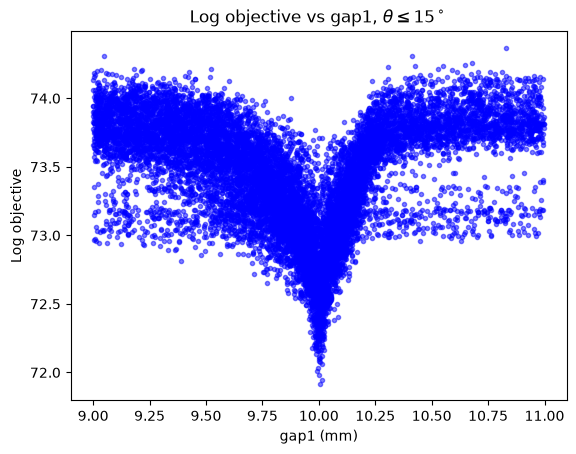

In [19]:
# sort by where theta is
small_theta_args = np.where(theta_vals<=15)
large_theta_args = np.where(theta_vals>15)
gap_1_small_theta = gap1_vals[small_theta_args]
gap_1_large_theta = gap1_vals[large_theta_args]
small_theta_values = values_arr[small_theta_args]
large_theta_values = values_arr[large_theta_args]

fig,ax=plt.subplots()
ax.scatter(gap_1_small_theta, np.log(small_theta_values), marker='.', c='b', alpha=0.5)
#ax.scatter(gap_1_large_theta, np.log(large_theta_values), marker='.', c='b', alpha=0.5)
ax.set_ylabel('Log objective')
ax.set_xlabel('gap1 (mm)')
ax.set_title('Log objective vs gap1, $\\theta\\leq15^\\circ$')
plt.show()

In [20]:
fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    gap1_vals_wid = gap1_vals[walker_id_args]
    values_wid = values_arr[walker_id_args]
    print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(gap1_vals_wid, np.log(values_wid), marker='.', c='b')
plt.tight_layout()
plt.show()

best result for walker id 0: 1.7119303620295577e+31
best result for walker id 1: 2.2444008368071343e+31
best result for walker id 2: 2.2589633615759326e+31
best result for walker id 3: 1.87403471120526e+31
best result for walker id 4: 2.426209811129673e+31
best result for walker id 5: 2.1271927419587635e+31
best result for walker id 6: 1.9139825267104367e+31
best result for walker id 7: 2.081229384764981e+31
best result for walker id 8: 1.824567283731694e+31
best result for walker id 9: 2.153531502706908e+31


KeyboardInterrupt: 

In [ ]:
best = np.argsort(values_arr)
t10_params = params_arr[best][:10]
print(values_arr[best][:10])
print(t10_params)

best_params = params_arr[best][0]
print(best_params)
print(mcmc.fom(best_params, verbose=True))

[1.71193036e+31 1.75698905e+31 1.82456728e+31 1.87403471e+31
 1.91398253e+31 1.97261881e+31 2.00573896e+31 2.01415772e+31
 2.05614580e+31 2.07216819e+31]
[[6.64824190e-01 1.20250169e+02 3.33057059e+00 1.00067577e+01
  1.11888175e+01 1.05143685e+01 1.13177544e+02 1.20734733e+02]
 [5.79408710e-01 1.22436327e+02 3.62519767e+00 1.00144176e+01
  1.21676561e+01 1.15180021e+01 1.13645286e+02 1.16767193e+02]
 [0.00000000e+00 1.25000000e+02 5.00000000e+00 1.00000000e+01
  6.00000000e+00 6.00000000e+00 1.25000000e+02 1.25000000e+02]
 [4.48810118e+00 1.02331021e+02 6.95755156e+00 9.99361911e+00
  6.52889607e+00 5.48652203e+00 1.23439131e+02 1.09029950e+02]
 [2.15071150e+00 1.26888987e+02 3.86425822e+00 9.99599015e+00
  7.78336221e+00 6.89821831e+00 1.19565251e+02 1.24570527e+02]
 [7.11741696e-12 1.19014362e+02 9.66898137e+00 1.00140326e+01
  7.41924722e+00 7.47538978e+00 1.11352896e+02 1.22267389e+02]
 [3.78865122e+00 1.09935855e+02 6.56418539e+00 1.00057126e+01
  6.25374128e+00 5.47552628e+00 1.

KeyboardInterrupt: 

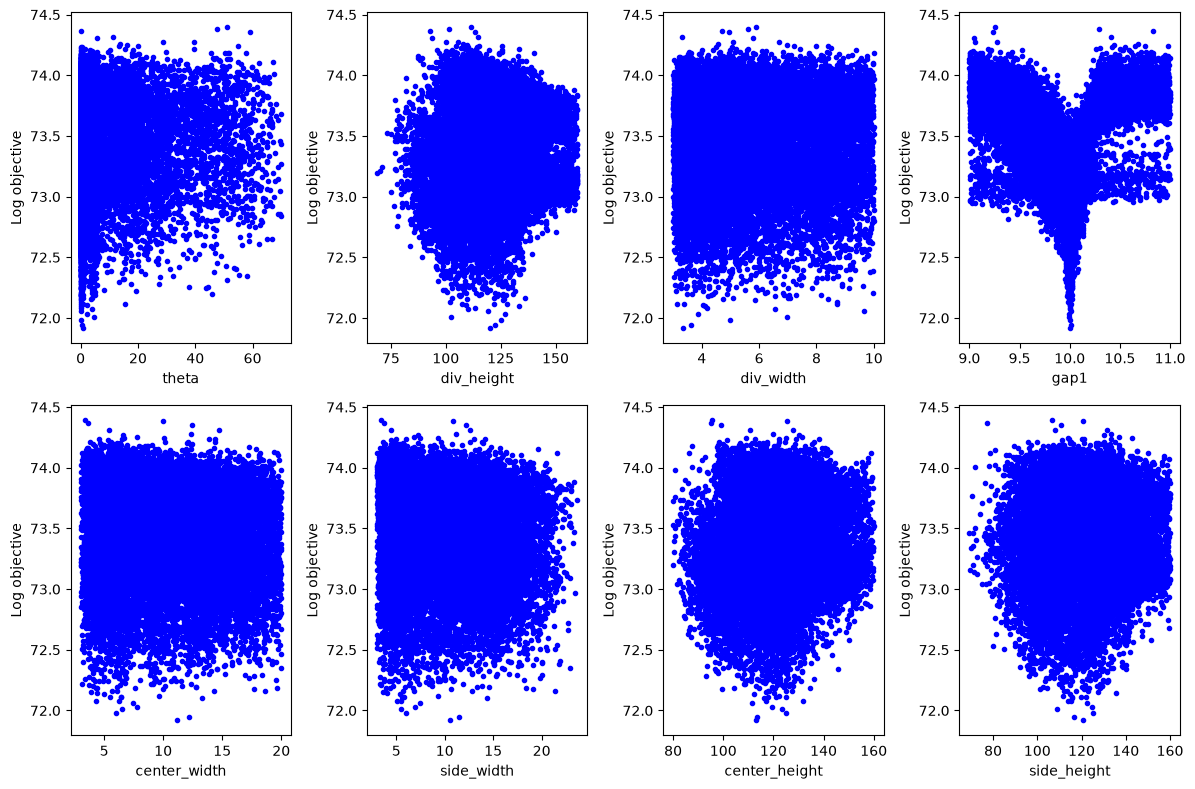

In [ ]:
param_names = ['theta', 'div_height', 'div_width', 'gap1', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

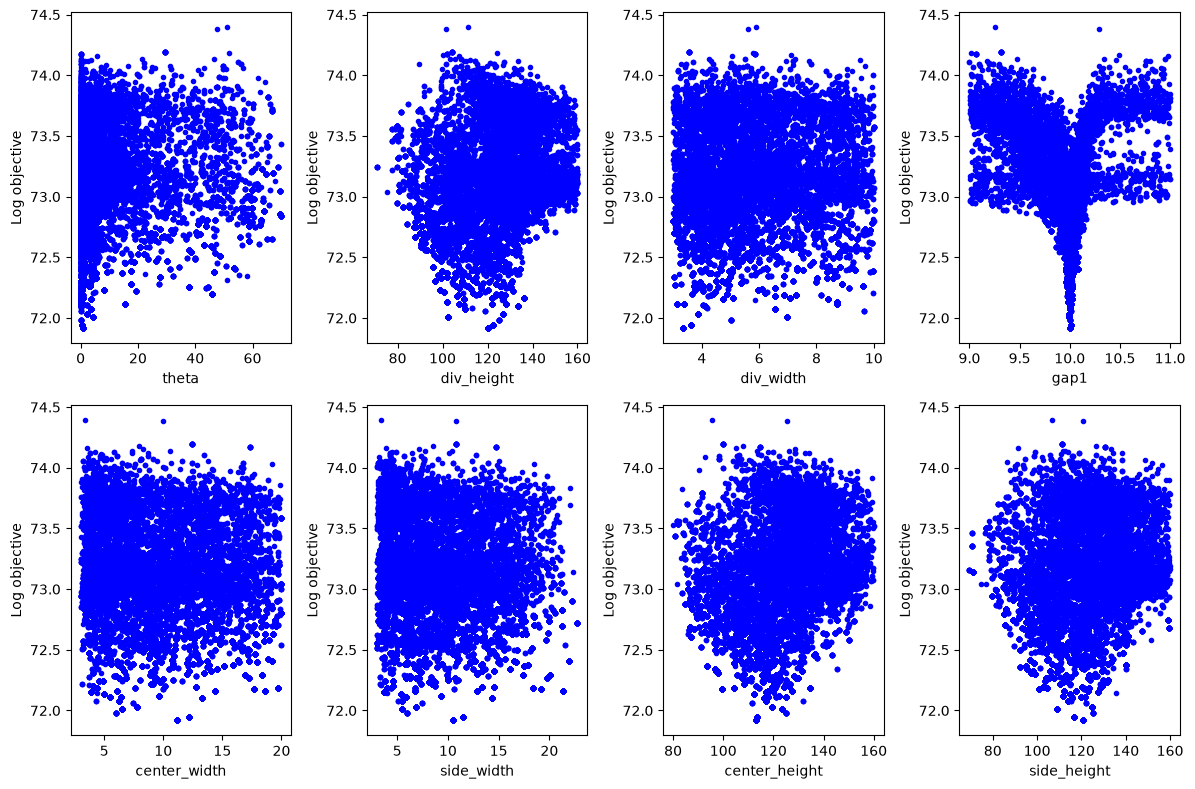

In [23]:
df_all = pd.read_csv('results/08_04_2026_mcmc_results/all_params_all_values.csv')
params_all = df_all['Parameters']
values_all = df_all['Value']
wid_all = df_all['Walker']
params_arr_all = []
values_arr_all = []
wid_arr_all = []

for i, param in enumerate(params_all):
    params_arr_all.append(mcmc._parse_params(param))
    values_arr_all.append(values_all.loc[i])
    wid_arr_all.append(wid_all.loc[i])

params_arr_all = np.asarray(params_arr_all)
values_arr_all = np.asarray(values_arr_all)
wid_arr_all = np.asarray(wid_arr_all)

ignore_args_all = np.where(values_arr_all!=1e+33)
values_arr_all = values_arr_all[ignore_args_all]
wid_arr_all = wid_arr_all[ignore_args_all]
params_arr_all = params_arr_all[ignore_args_all]

param_names = ['theta', 'div_height', 'div_width', 'gap1', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

3500


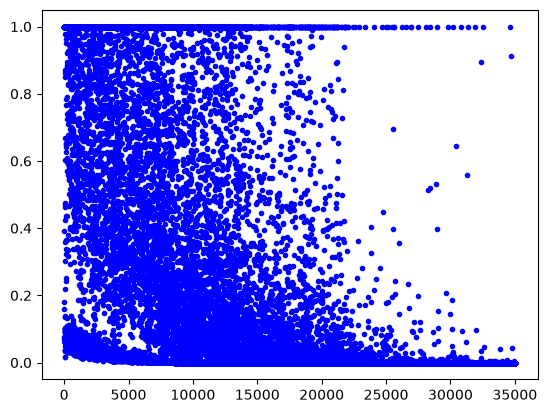

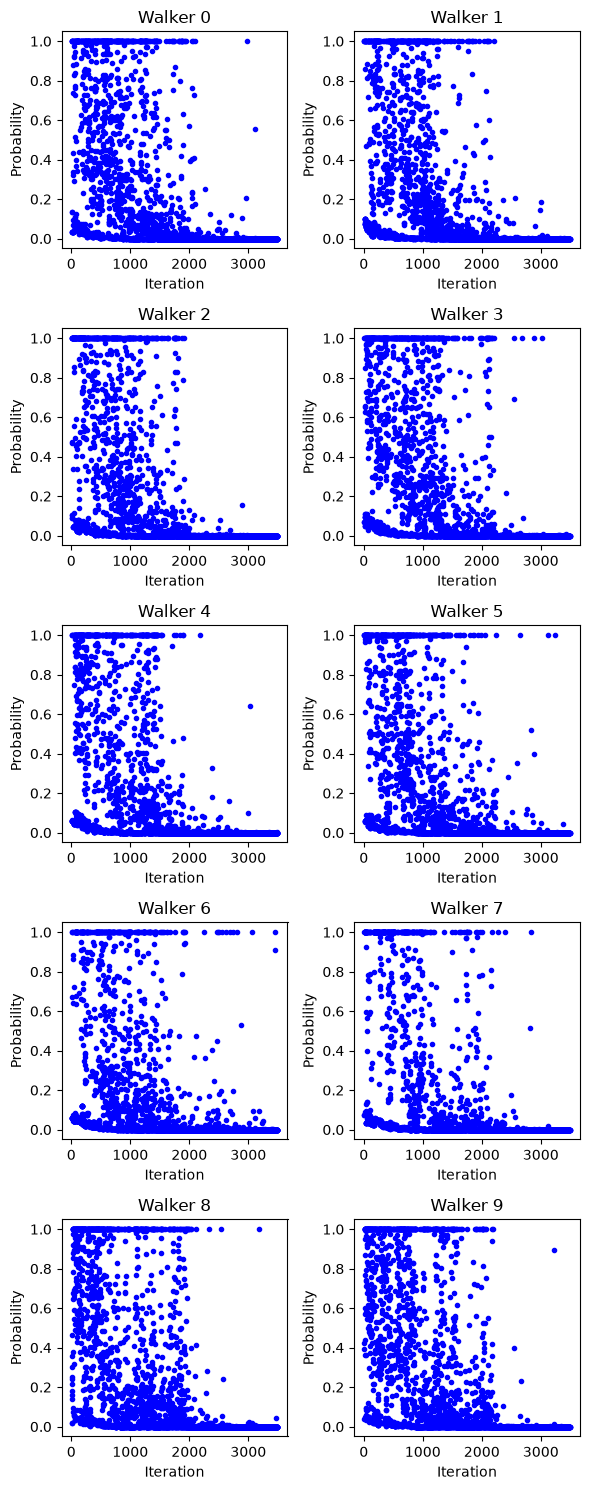

In [32]:
probs = df["AcceptProb"]
fig, ax = plt.subplots()
ax.scatter(probs[-np.isnan(df["AcceptProb"])].index, probs[-np.isnan(df["AcceptProb"])], marker='.', c='b')

probs = np.asarray(probs)
wid_arr = np.asarray(wid)

fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    probs_wid = probs[walker_id_args]
    probs_wid = probs_wid[~np.isnan(probs_wid)]
    inds = np.linspace(10, len(probs_wid)-10, len(probs_wid))
    #print(len(inds))
    #print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(inds, probs_wid, marker='.', c='b')
    ax_flat[walker_id].set_title(f'Walker {walker_id}')
    ax_flat[walker_id].set_xlabel('Iteration')
    ax_flat[walker_id].set_ylabel('Probability')

print(len(inds))
plt.tight_layout()
plt.show()


range for theta: [np.float64(0.0), np.float64(15.4268862)]
range for div_height: [np.float64(101.876148), np.float64(136.16826504)]
range for div_width: [np.float64(3.1198311), np.float64(9.66898137)]
range for gap1: [np.float64(9.97123087), np.float64(10.02388389)]
range for center_width: [np.float64(3.88802426), np.float64(19.6672269)]
range for side_width: [np.float64(3.67938), np.float64(21.37607706)]
range for center_height: [np.float64(99.3436279), np.float64(134.604879)]
range for side_height: [np.float64(100.993283), np.float64(135.696091)]


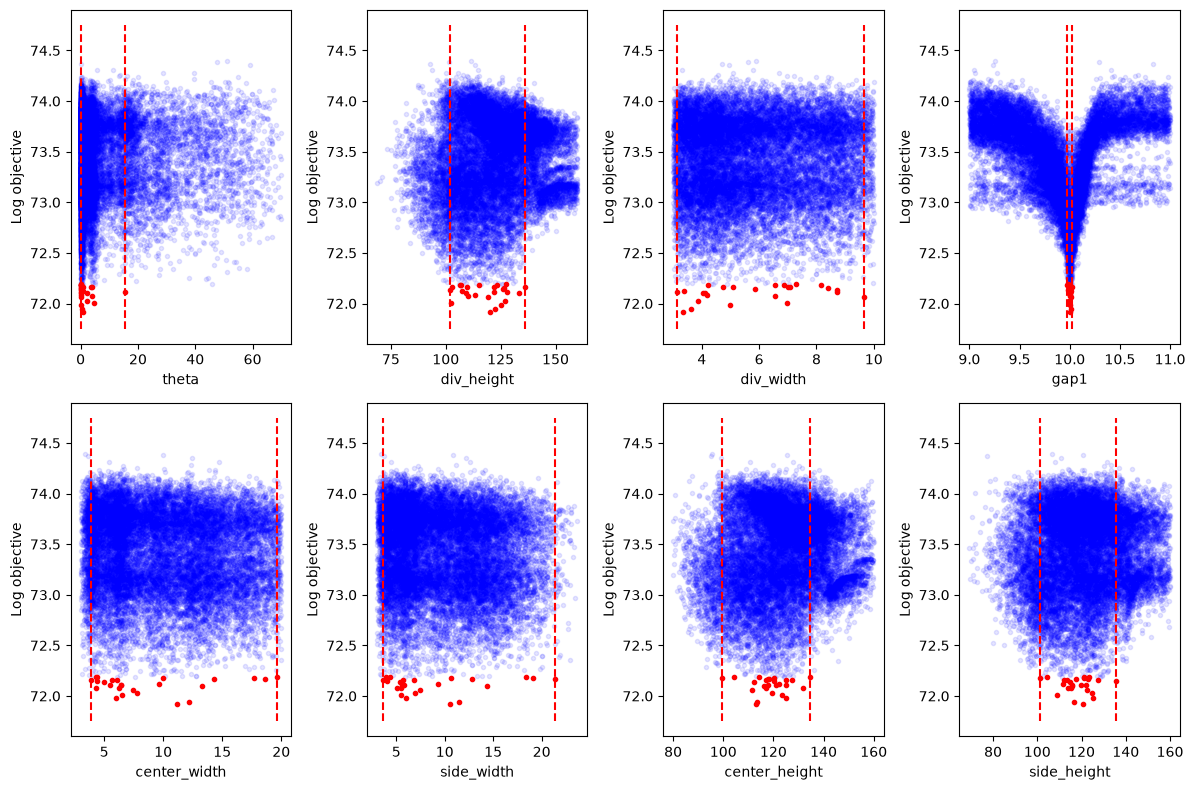

In [27]:
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

n = 25
tn_params = params_arr[best][:n]

for i, name in enumerate(param_names):
    #print(f'optimal {name}s: {t10_params[:,i]}\n')
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.', alpha=0.1)
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")
    ax_flat[i].vlines([np.min(tn_params[:,i]), np.max(tn_params[:,i])], 71.75, 74.75, colors='r', ls='--')
    print(f'range for {name}: {[np.min(tn_params[:,i]), np.max(tn_params[:,i])]}')
    ax_flat[i].scatter(tn_params[:,i], np.log(values_arr[best][:n]), c='r', marker='.')

plt.tight_layout()
plt.show()

In [35]:
print(mcmc.fom([43.08239729, 128.44919526, 5.33452249, 9.99969355, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))
print()
print(mcmc.fom([0, 128.44919526, 5.33452249, 10, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))


  x= -0.00 y=  0.00  guess= 15.000  f= 15.008 GHz  C=0.5124  Q=    7618  loc=0.451
  x= -0.58 y=  0.55  guess= 14.173  f= 14.206 GHz  C=0.2609  Q=    7695  loc=0.178
  x= -1.17 y=  1.09  guess= 13.433  f= 13.473 GHz  C=0.2611  Q=    7929  loc=0.173
  x= -1.75 y=  1.64  guess= 12.766  f= 12.819 GHz  C=0.2532  Q=    8328  loc=0.189
  x= -2.33 y=  2.18  guess= 12.162  f= 12.221 GHz  C=0.2080  Q=    8705  loc=0.163
  x= -2.92 y=  2.73  guess= 11.613  f= 11.646 GHz  C=0.2937  Q=    8765  loc=0.260
  x= -3.50 y=  3.27  guess= 11.111  f= 11.169 GHz  C=0.2068  Q=    9208  loc=0.172
  x= -4.08 y=  3.82  guess= 10.651  f= 10.686 GHz  C=0.2231  Q=    9239  loc=0.199
  x= -4.67 y=  4.36  guess= 10.227  f= 10.279 GHz  C=0.2249  Q=    9212  loc=0.142
  x= -5.25 y=  4.91  guess=  9.836  f=  9.892 GHz  C=0.2314  Q=    9487  loc=0.166
  x= -5.83 y=  5.46  guess=  9.474  f=  9.541 GHz  C=0.2089  Q=    9597  loc=0.148
  x= -6.42 y=  6.00  guess=  9.137  f=  9.216 GHz  C=0.1799  Q=    9825  loc=0.160
  x=